# Ensembling e Stacking


## Configuração Inicial (Setup)


In [1]:
import json
import logging
import os
import tempfile
import warnings

import matplotlib.pyplot as plt
import mlflow
import numpy as np
import pandas as pd
import seaborn as sns
from dotenv import load_dotenv
from IPython.display import display
from sklearn.linear_model import (
    HuberRegressor,
    LassoCV,
    LinearRegression,
    Ridge,
)
from sklearn.metrics import r2_score
from sklearn.model_selection import GridSearchCV, LeaveOneGroupOut

load_dotenv()

ROOT_PATH = os.path.dirname(os.getcwd())
DATA_FOLDER_PATH = os.path.join(ROOT_PATH, 'data', 'processed')

COVID_START = pd.Timestamp('2020-04-01')  # first pandemic month: April 2020
COVID_END = pd.Timestamp('2021-12-31')
SEASONAL_PERIOD = 12
TARGET = 'arrival_count'
FREQ = 'ME'

sns.set_palette('colorblind')
pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 200)
logging.getLogger('mlflow').setLevel(logging.ERROR)
warnings.filterwarnings('ignore', category=FutureWarning)
mlflow.set_tracking_uri(os.getenv('MLFLOW_TRACKING_URI'))
client = mlflow.MlflowClient()
EXPERIMENT_NAME = 'Brazil Tourism Forecasting Ensembles'
experiment = mlflow.set_experiment(EXPERIMENT_NAME)

## 1. A Melhor Previsão de Cada Abordagem

Recupera as previsões de validação registradas no MLflow das melhores configurações
de SARIMAX (notebook 5), ML Local (notebook 7), ML Global (notebook 8) e TimesFM (notebook 9).


In [2]:
EXPERIMENTS = {
    'SARIMAX': 'Brazil Tourism Forecasting ARIMA',
    'Local ML': 'Brazil Tourism Forecasting ML',
    'Global ML': 'Brazil Tourism Forecasting ML Global',
    'TimesFM': 'Brazil Tourism Forecasting TimesFM',
}
APPROACHES = list(EXPERIMENTS)


def load_best_forecasts(approach, experiment_name):
    """The latest `best_validation_forecasts` run of an experiment and its forecasts."""
    found = mlflow.get_experiment_by_name(experiment_name)
    assert found is not None, f'{approach}: run its notebook first ({experiment_name})'
    runs = client.search_runs(
        [found.experiment_id],
        filter_string="tags.role = 'best_validation_forecasts'",
        order_by=['attributes.start_time DESC'],
        max_results=1,
    )
    assert runs, f'{approach}: run the last section of its notebook first'
    path = mlflow.artifacts.download_artifacts(
        run_id=runs[0].info.run_id,
        artifact_path='validation_forecasts.csv',
        dst_path=tempfile.mkdtemp(),
    )
    return runs[0], pd.read_csv(path, parse_dates=['date'])


members, frames = {}, {}
for approach, experiment_name in EXPERIMENTS.items():
    run, frames[approach] = load_best_forecasts(approach, experiment_name)
    members[approach] = {
        'configuration': run.data.params['configuration'],
        'MASE_mean (logged)': run.data.metrics['MASE_mean'],
        'origins': run.data.params['origins'],
    }

# one row per (origin, month), one column per approach
forecasts = pd.concat(
    {a: f.set_index(['origin', 'date'])['forecast'] for a, f in frames.items()}, axis=1
)
forecasts['actual'] = frames[APPROACHES[0]].set_index(['origin', 'date'])['actual']
for approach, frame in frames.items():
    actual = frame.set_index(['origin', 'date'])['actual']
    assert np.allclose(actual, forecasts['actual']), f'{approach}: different actuals'
assert not forecasts.isna().any().any(), 'the approaches cover different months'

ORIGIN_LABELS = sorted(forecasts.index.get_level_values('origin').unique())
print(f'{len(forecasts)} validation months at origins {ORIGIN_LABELS}')
pd.DataFrame(members).T

48 validation months at origins ['2017-08', '2018-08', '2023-08', '2024-08']


,configuration,MASE_mean (logged),origins
SARIMAX,"SARIMAX(0,1,2)(0,1,1)[12] (last_4y_covid_recov...",0.992006,"2017-08, 2018-08, 2023-08, 2024-08"
Local ML,XGBoost | seasonal_log_diff | last_4y | keep |...,0.98228,"2017-08, 2018-08, 2023-08, 2024-08"
Global ML,XGBoost | seasonal_log_diff | last_6y | keep |...,1.101019,"2017-08, 2018-08, 2023-08, 2024-08"
TimesFM,all | remove | none | calendar | symmetric,1.31229,"2017-08, 2018-08, 2023-08, 2024-08"


## 2. Avaliação de Métricas (Scoring)

Os dados observados são obtidos de `train_ptbr.parquet` e `val_ptbr.parquet` (o conjunto de teste nunca é lido aqui).


In [3]:
def load_monthly(file_name):
    raw = pd.read_parquet(os.path.join(DATA_FOLDER_PATH, file_name))
    return raw.set_index('date')[TARGET].resample(FREQ).sum()


# train + validation (the test set is never read)
full_series = pd.concat([load_monthly('train_ptbr.parquet'), load_monthly('val_ptbr.parquet')])
MASE_EXCLUDED = (COVID_START, pd.Timestamp('2022-12-31'))


def origin_date(label):
    return pd.Timestamp(label) + pd.offsets.MonthEnd(0)


ORIGINS = {label: origin_date(label) for label in ORIGIN_LABELS}
LATEST = ORIGIN_LABELS[-1]  # its validation window is val_ptbr.parquet
POST_COVID = [label for label, origin in ORIGINS.items() if origin > COVID_END]


def seasonal_mase_scale(history):
    """In-sample MAE of the seasonal naive (y_t - y_{t-12}), pandemic pairs excluded."""
    diffs = (history - history.shift(SEASONAL_PERIOD)).abs()
    in_pandemic = history.index.to_series().between(*MASE_EXCLUDED)
    touches = in_pandemic | in_pandemic.shift(SEASONAL_PERIOD, fill_value=False)
    return float(diffs[~touches.to_numpy()].mean())


MASE_SCALES = {
    label: seasonal_mase_scale(full_series.loc[:origin])
    for label, origin in ORIGINS.items()
}
METRICS = ['RMSE', 'MAE', 'MAPE', 'R2', 'MASE', 'Forecast Bias']


def score(actual, predicted, label):
    actual, predicted = np.asarray(actual, float), np.asarray(predicted, float)
    errors = actual - predicted
    mae = float(np.mean(np.abs(errors)))
    return {
        'RMSE': float(np.sqrt(np.mean(errors**2))),
        'MAE': mae,
        'MAPE': float(np.mean(np.abs(errors / actual)) * 100),
        'R2': float(r2_score(actual, predicted)),
        'MASE': mae / MASE_SCALES[label],
        'Forecast Bias': float((actual.sum() - predicted.sum()) / actual.sum() * 100),
    }


def evaluate(predicted):
    """Scores of one forecast Series (indexed like `forecasts`) at every origin."""
    per_origin = {
        label: score(forecasts.loc[label, 'actual'], predicted.loc[label], label)
        for label in ORIGIN_LABELS
    }
    mase = pd.Series({label: s['MASE'] for label, s in per_origin.items()})
    return {
        **{f'MASE {label}': value for label, value in mase.items()},
        'MASE_mean': float(mase.mean()),
        'MASE_worst': float(mase.max()),
        'MASE_post': float(mase[POST_COVID].mean()),
        **per_origin[LATEST],
    }


# seasonal naive: the same month one year earlier, at every origin
seasonal_naive = pd.Series(
    [full_series.get(date - pd.offsets.MonthEnd(12)) for _, date in forecasts.index],
    index=forecasts.index,
)

results = {'seasonal naive': evaluate(seasonal_naive)}
for approach in APPROACHES:
    results[approach] = evaluate(forecasts[approach])
    logged = members[approach]['MASE_mean (logged)']
    assert np.isclose(results[approach]['MASE_mean'], logged), (approach, logged)
print('Recomputed MASE_mean matches the value logged by every notebook')

# identify the best 2 overall models by lowest MASE_mean
BEST_2_APPROACHES = sorted(APPROACHES, key=lambda a: results[a]['MASE_mean'])[:2]
print(f'Best 2 overall single models: {BEST_2_APPROACHES}')

pd.DataFrame(results).T.round(3)


Recomputed MASE_mean matches the value logged by every notebook
Best 2 overall single models: ['Local ML', 'SARIMAX']


,MASE 2017-08,MASE 2018-08,MASE 2023-08,MASE 2024-08,MASE_mean,MASE_worst,MASE_post,RMSE,MAE,MAPE,R2,MASE,Forecast Bias
seasonal naive,0.680,0.977,1.463,4.024,1.786,4.024,2.743,255353.116,209126.083,26.478,0.407,4.024,28.357
SARIMAX,0.723,0.970,1.017,1.258,0.992,1.258,1.137,103693.084,65358.584,7.302,0.902,1.258,7.931
Local ML,0.756,1.063,0.932,1.179,0.982,1.179,1.055,80115.966,61259.475,7.788,0.942,1.179,-1.349
Global ML,1.308,0.591,0.943,1.563,1.101,1.563,1.253,125101.593,81214.072,9.051,0.858,1.563,9.463
TimesFM,0.912,0.701,0.808,2.829,1.312,2.829,1.818,184216.923,147015.578,17.815,0.691,2.829,19.935


## 3. Ensembles Simples: Média, Mediana e Média Ponderada pelo Inverso do MASE


In [4]:
ensembles = {
    'mean (all)': forecasts[APPROACHES].mean(axis=1),
    'median (all)': forecasts[APPROACHES].median(axis=1),
    'mean (best 2)': forecasts[BEST_2_APPROACHES].mean(axis=1),
}
for name, predicted in ensembles.items():
    results[name] = evaluate(predicted)
pd.DataFrame({name: results[name] for name in ensembles}).T.round(3)


,MASE 2017-08,MASE 2018-08,MASE 2023-08,MASE 2024-08,MASE_mean,MASE_worst,MASE_post,RMSE,MAE,MAPE,R2,MASE,Forecast Bias
mean (all),0.764,0.797,0.856,1.377,0.949,1.377,1.117,111889.892,71568.901,7.778,0.886,1.377,8.995
median (all),0.684,0.926,0.915,1.410,0.984,1.410,1.162,114113.785,73286.328,8.177,0.882,1.410,8.697
mean (best 2),0.691,1.014,0.957,1.066,0.932,1.066,1.011,83465.433,55389.785,6.045,0.937,1.066,3.291


### Média Ponderada pelo Inverso do MASE (Inverse-MASE Weighted Mean)


In [5]:
def inverse_mase_weights(labels, members_list):
    """Weights proportional to 1 / mean seasonal MASE over the given origins."""
    mase = pd.Series({
        approach: np.mean([results[approach][f'MASE {label}'] for label in labels])
        for approach in members_list
    })
    inverse = 1 / mase
    return inverse / inverse.sum()


for subset_label, members_list in [('all', APPROACHES), ('best 2', BEST_2_APPROACHES)]:
    name = f'inverse-MASE mean ({subset_label})'
    inv_series = pd.Series(np.nan, index=forecasts.index)
    table = {}
    for held_out in ORIGIN_LABELS:
        w = inverse_mase_weights([l for l in ORIGIN_LABELS if l != held_out], members_list)
        held = forecasts.xs(held_out, level='origin', drop_level=False)
        inv_series.loc[held.index] = held[members_list].to_numpy() @ w[members_list].to_numpy()
        table[f'held out {held_out}'] = w
    ensembles[name] = inv_series
    results[name] = evaluate(inv_series)

    final_w = inverse_mase_weights(ORIGIN_LABELS, members_list)
    table['all 4 origins (final)'] = final_w
    print(f'=== Weights for {name} ===')
    display(pd.DataFrame(table).T.round(3))

pd.DataFrame({
    name: results[name]
    for name in [
        'mean (all)',
        'median (all)',
        'inverse-MASE mean (all)',
        'mean (best 2)',
        'inverse-MASE mean (best 2)',
    ]
}).T.round(3)


=== Weights for inverse-MASE mean (all) ===


,SARIMAX,Local ML,Global ML,TimesFM
held out 2017-08,0.262,0.268,0.274,0.196
held out 2018-08,0.286,0.300,0.225,0.189
held out 2023-08,0.286,0.281,0.244,0.190
held out 2024-08,0.246,0.243,0.235,0.276
all 4 origins (final),0.273,0.275,0.246,0.206


=== Weights for inverse-MASE mean (best 2) ===


,Local ML,SARIMAX
held out 2017-08,0.506,0.494
held out 2018-08,0.511,0.489
held out 2023-08,0.496,0.504
held out 2024-08,0.496,0.504
all 4 origins (final),0.502,0.498


,MASE 2017-08,MASE 2018-08,MASE 2023-08,MASE 2024-08,MASE_mean,MASE_worst,MASE_post,RMSE,MAE,MAPE,R2,MASE,Forecast Bias
mean (all),0.764,0.797,0.856,1.377,0.949,1.377,1.117,111889.892,71568.901,7.778,0.886,1.377,8.995
median (all),0.684,0.926,0.915,1.410,0.984,1.410,1.162,114113.785,73286.328,8.177,0.882,1.410,8.697
inverse-MASE mean (all),0.757,0.836,0.873,1.416,0.971,1.416,1.144,113729.239,73573.258,8.028,0.882,1.416,9.350
mean (best 2),0.691,1.014,0.957,1.066,0.932,1.066,1.011,83465.433,55389.785,6.045,0.937,1.066,3.291
inverse-MASE mean (best 2),0.691,1.015,0.957,1.066,0.932,1.066,1.011,83560.907,55385.892,6.039,0.936,1.066,3.325


## 4. Stacking: Regressões Huber, Linear, Ridge e Lasso


In [6]:
HUBER_PARAMS = {
    'epsilon': 1.35,
    'alpha': 1e-4,
    'fit_intercept': False,
    'max_iter': 1000,
}
SCALE = 1e5


def fit_huber(rows, members_list):
    return HuberRegressor(**HUBER_PARAMS).fit(
        rows[members_list] / SCALE, rows['actual'] / SCALE
    )


final_huber_models = {}
for subset_label, members_list in [('all', APPROACHES), ('best 2', BEST_2_APPROACHES)]:
    name = f'huber stacking ({subset_label})'
    stacked = pd.Series(np.nan, index=forecasts.index)
    fold_weights = {}
    for held_out in ORIGIN_LABELS:
        train = forecasts.drop(index=held_out, level='origin')
        model = fit_huber(train, members_list)
        held = forecasts.xs(held_out, level='origin', drop_level=False)
        stacked.loc[held.index] = model.predict(held[members_list] / SCALE) * SCALE
        fold_weights[f'held out {held_out}'] = dict(zip(members_list, model.coef_))

    ensembles[name] = stacked
    results[name] = evaluate(stacked)

    weights_df = pd.DataFrame(fold_weights).T
    weights_df['sum of weights'] = weights_df.sum(axis=1)
    final_model = fit_huber(forecasts, members_list)
    final_huber_models[name] = final_model
    weights_df.loc['all 4 origins (final)'] = [*final_model.coef_, final_model.coef_.sum()]
    print(f'=== Weights for {name} ===')
    display(weights_df.round(3))

pd.DataFrame({
    name: results[name] for name in ['huber stacking (all)', 'huber stacking (best 2)']
}).T.round(3)


=== Weights for huber stacking (all) ===


,SARIMAX,Local ML,Global ML,TimesFM,sum of weights
held out 2017-08,-1.338,0.805,1.073,0.477,1.016
held out 2018-08,-0.278,0.685,0.194,0.423,1.024
held out 2023-08,-0.018,0.738,0.215,0.048,0.983
held out 2024-08,-0.615,0.704,0.105,0.812,1.007
all 4 origins (final),-0.553,0.873,0.207,0.478,1.005


=== Weights for huber stacking (best 2) ===


,Local ML,SARIMAX,sum of weights
held out 2017-08,0.639,0.345,0.984
held out 2018-08,0.574,0.421,0.995
held out 2023-08,0.642,0.335,0.978
held out 2024-08,0.607,0.363,0.969
all 4 origins (final),0.652,0.328,0.980


,MASE 2017-08,MASE 2018-08,MASE 2023-08,MASE 2024-08,MASE_mean,MASE_worst,MASE_post,RMSE,MAE,MAPE,R2,MASE,Forecast Bias
huber stacking (all),1.306,0.958,0.920,1.537,1.180,1.537,1.229,122421.637,79899.051,8.557,0.864,1.537,10.689
huber stacking (best 2),0.646,0.988,0.987,1.165,0.946,1.165,1.076,92382.527,60561.217,6.428,0.922,1.165,5.113


### Stacking Não-Negativo: Regressão Linear, Ridge e Lasso


In [7]:
RIDGE_ALPHAS = np.logspace(-3, 3, 13)


def inner_splits(rows):
    """Leave-one-origin-out splits inside the training origins (for the penalty)."""
    origins = rows.index.get_level_values('origin')
    return list(LeaveOneGroupOut().split(rows, groups=origins))


def fit_linear(rows, members_list):
    """Non-negative least squares: no penalty, so no alpha to choose."""
    model = LinearRegression(positive=True, fit_intercept=False)
    return model.fit(rows[members_list] / SCALE, rows['actual'] / SCALE), np.nan


def fit_ridge(rows, members_list):
    search = GridSearchCV(
        Ridge(positive=True, fit_intercept=False),
        {'alpha': RIDGE_ALPHAS},
        cv=inner_splits(rows),
        scoring='neg_mean_squared_error',
    ).fit(rows[members_list] / SCALE, rows['actual'] / SCALE)
    return search.best_estimator_, search.best_params_['alpha']


def fit_lasso(rows, members_list):
    model = LassoCV(
        alphas=50,
        positive=True,
        fit_intercept=False,
        cv=inner_splits(rows),
        max_iter=10000,
    ).fit(rows[members_list] / SCALE, rows['actual'] / SCALE)
    return model, model.alpha_


NON_NEGATIVE_STACKERS = {
    'linear stacking': fit_linear,
    'ridge stacking': fit_ridge,
    'lasso stacking': fit_lasso,
}
final_stackers = {}

for subset_label, members_list in [('all', APPROACHES), ('best 2', BEST_2_APPROACHES)]:
    for base_name, fit in NON_NEGATIVE_STACKERS.items():
        name = f'{base_name} ({subset_label})'
        stacked_forecast = pd.Series(np.nan, index=forecasts.index)
        fold_table = {}
        for held_out in ORIGIN_LABELS:
            model, alpha = fit(forecasts.drop(index=held_out, level='origin'), members_list)
            held = forecasts.xs(held_out, level='origin', drop_level=False)
            stacked_forecast.loc[held.index] = (
                model.predict(held[members_list] / SCALE) * SCALE
            )
            fold_table[f'held out {held_out}'] = {
                **dict(zip(members_list, model.coef_)),
                'alpha': alpha,
            }
        ensembles[name] = stacked_forecast
        results[name] = evaluate(stacked_forecast)

        final_stackers[name] = fit(forecasts, members_list)
        final_fit, final_alpha = final_stackers[name]
        fold_table['all 4 origins (final)'] = {
            **dict(zip(members_list, final_fit.coef_)),
            'alpha': final_alpha,
        }
        table = pd.DataFrame(fold_table).T
        table.insert(len(members_list), 'sum of weights', table[members_list].sum(axis=1))
        print(f'=== {name} ===')
        display(table.round(3))

STACKERS = [
    'huber stacking (all)',
    'linear stacking (all)',
    'ridge stacking (all)',
    'lasso stacking (all)',
    'huber stacking (best 2)',
    'linear stacking (best 2)',
    'ridge stacking (best 2)',
    'lasso stacking (best 2)',
]
pd.DataFrame({name: results[name] for name in STACKERS}).T.round(3)


=== linear stacking (all) ===


,SARIMAX,Local ML,Global ML,TimesFM,sum of weights,alpha
held out 2017-08,0.0,0.538,0.468,0.000,1.006,NaN
held out 2018-08,0.0,0.657,0.133,0.243,1.033,NaN
held out 2023-08,0.0,0.678,0.322,0.000,1.000,NaN
held out 2024-08,0.0,0.274,0.279,0.449,1.002,NaN
all 4 origins (final),0.0,0.666,0.327,0.005,0.997,NaN


=== ridge stacking (all) ===


,SARIMAX,Local ML,Global ML,TimesFM,sum of weights,alpha
held out 2017-08,0.214,0.331,0.296,0.180,1.022,31.623
held out 2018-08,0.246,0.335,0.233,0.237,1.051,31.623
held out 2023-08,0.000,0.678,0.322,0.000,1.000,0.001
held out 2024-08,0.213,0.254,0.256,0.263,0.986,31.623
all 4 origins (final),0.218,0.346,0.276,0.180,1.021,31.623


=== lasso stacking (all) ===


...

=== ridge stacking (best 2) ===


,Local ML,SARIMAX,sum of weights,alpha
held out 2017-08,0.670,0.318,0.988,0.032
held out 2018-08,0.857,0.135,0.992,0.001
held out 2023-08,0.967,0.000,0.967,0.032
held out 2024-08,0.688,0.266,0.954,0.010
all 4 origins (final),0.686,0.303,0.989,0.100


=== lasso stacking (best 2) ===


,Local ML,SARIMAX,sum of weights,alpha
held out 2017-08,0.958,0.0,0.958,0.362
held out 2018-08,0.974,0.0,0.974,0.426
held out 2023-08,0.955,0.0,0.955,0.569
held out 2024-08,0.934,0.0,0.934,0.378
all 4 origins (final),0.963,0.0,0.963,0.149


,MASE 2017-08,MASE 2018-08,MASE 2023-08,MASE 2024-08,MASE_mean,MASE_worst,MASE_post,RMSE,MAE,MAPE,R2,MASE,Forecast Bias
huber stacking (all),1.306,0.958,0.920,1.537,1.180,1.537,1.229,122421.637,79899.051,8.557,0.864,1.537,10.689
linear stacking (all),0.758,1.133,0.904,1.600,1.099,1.600,1.252,124142.486,83160.743,9.130,0.860,1.600,11.002
ridge stacking (all),0.717,1.206,0.904,1.545,1.093,1.545,1.225,120706.150,80318.891,8.914,0.867,1.545,10.394
lasso stacking (all),0.753,0.927,0.939,1.503,1.031,1.503,1.221,115772.913,78132.373,8.549,0.878,1.503,8.854
huber stacking (best 2),0.646,0.988,0.987,1.165,0.946,1.165,1.076,92382.527,60561.217,6.428,0.922,1.165,5.113
linear stacking (best 2),0.659,0.994,0.971,1.221,0.961,1.221,1.096,93234.627,63464.956,6.834,0.921,1.221,4.315
ridge stacking (best 2),0.654,0.994,0.971,1.228,0.962,1.228,1.099,96656.808,63827.758,6.773,0.915,1.228,5.809
lasso stacking (best 2),0.682,0.942,0.998,1.261,0.971,1.261,1.129,97756.366,65511.991,6.957,0.913,1.261,5.366


## 5. Resultados


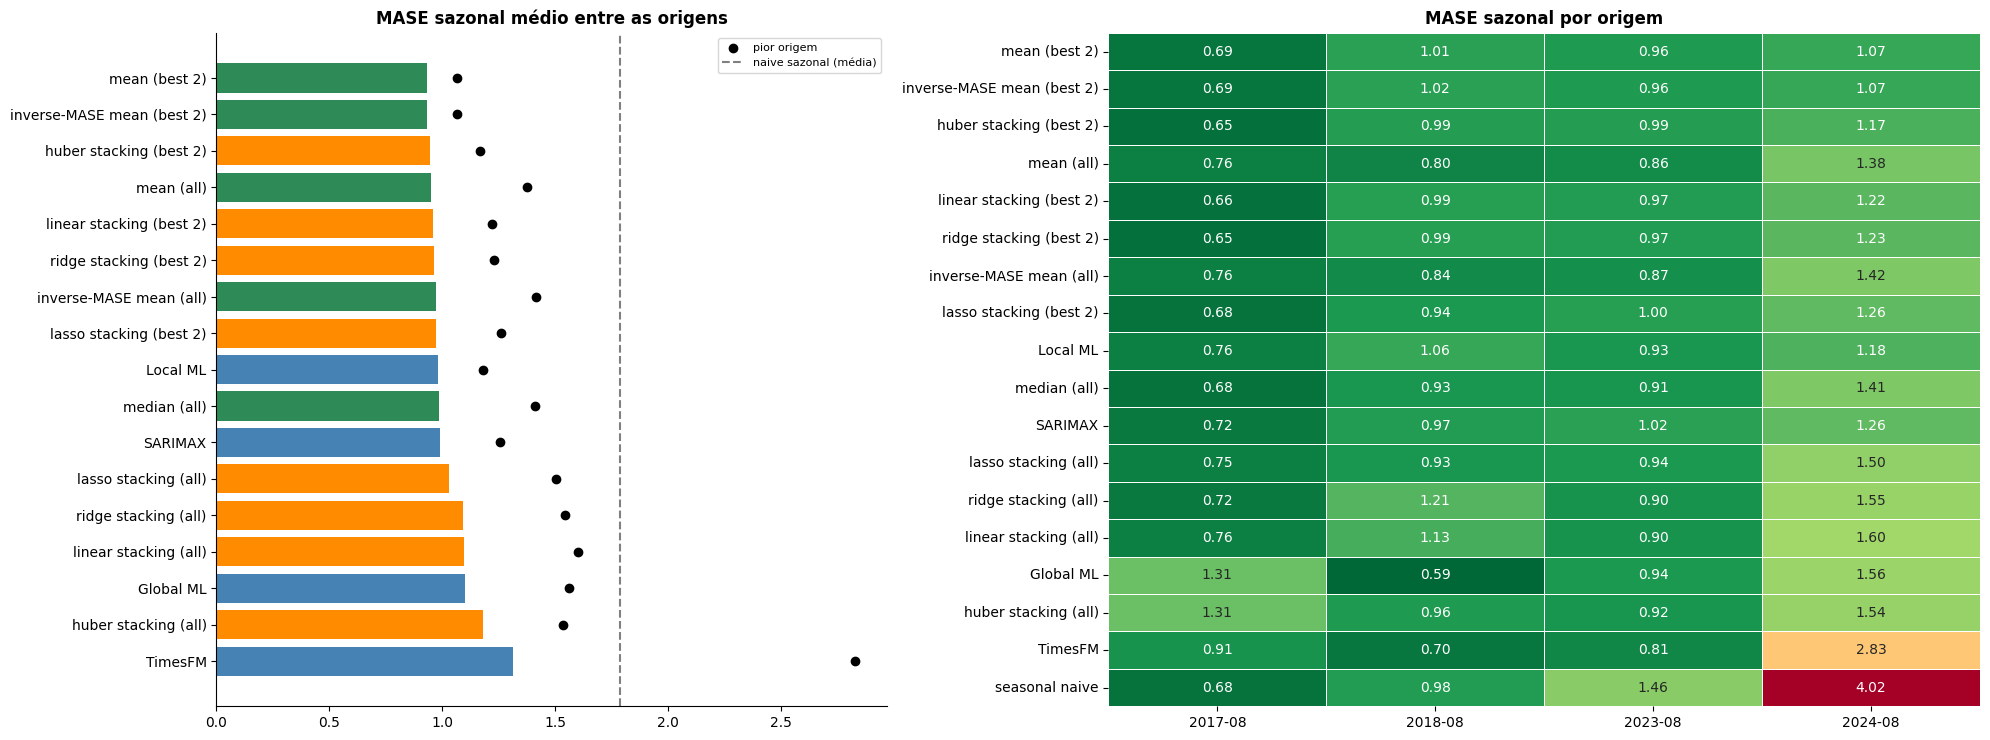

,kind,subset,MASE 2017-08,MASE 2018-08,MASE 2023-08,MASE 2024-08,MASE_mean,MASE_worst,MASE_post,RMSE,MAPE,R2,Forecast Bias,beats best single
mean (best 2),ensemble,best 2,0.691,1.014,0.957,1.066,0.932,1.066,1.011,83465.433,6.045,0.937,3.291,True
inverse-MASE mean (best 2),ensemble,best 2,0.691,1.015,0.957,1.066,0.932,1.066,1.011,83560.907,6.039,0.936,3.325,True
huber stacking (best 2),stacking,best 2,0.646,0.988,0.987,1.165,0.946,1.165,1.076,92382.527,6.428,0.922,5.113,True
mean (all),ensemble,all,0.764,0.797,0.856,1.377,0.949,1.377,1.117,111889.892,7.778,0.886,8.995,True
linear stacking (best 2),stacking,best 2,0.659,0.994,0.971,1.221,0.961,1.221,1.096,93234.627,6.834,0.921,4.315,True
ridge stacking (best 2),stacking,best 2,0.654,0.994,0.971,1.228,0.962,1.228,1.099,96656.808,6.773,0.915,5.809,True
inverse-MASE mean (all),ensemble,all,0.757,0.836,0.873,1.416,0.971,1.416,1.144,113729.239,8.028,0.882,9.350,True
lasso stacking (best 2),stacking,best 2,0.682,0.942,0.998,1.261,0.971,1.261,1.129,97756.366,6.957,0.913,5.366,True
Local ML,single model,-,0.756,1.063,0.932,1.179,0.982,1.179,1.055,80115.966,7.788,0.942,-1.349,False
median (all),ensemble,all,0.684,0.926,0.915,1.410,0.984,1.410,1.162,114113.785,8.177,0.882,8.697,False


In [8]:
KIND = {
    **dict.fromkeys(APPROACHES, 'single model'),
    'seasonal naive': 'baseline',
}
SUBSET = {
    **dict.fromkeys(APPROACHES, '-'),
    'seasonal naive': '-',
}
for name in ensembles:
    if 'stacking' in name:
        KIND[name] = 'stacking'
    else:
        KIND[name] = 'ensemble'
    SUBSET[name] = 'best 2' if '(best 2)' in name else 'all'

COLORS = {
    'single model': 'steelblue',
    'ensemble': 'seagreen',
    'stacking': 'darkorange',
    'baseline': 'grey',
}
summary = pd.DataFrame(results).T.sort_values('MASE_mean')
summary.insert(0, 'kind', summary.index.map(KIND))
summary.insert(1, 'subset', summary.index.map(SUBSET))
best_single = summary[summary['kind'] == 'single model'].index[0]
summary['beats best single'] = (
    summary['MASE_mean'] < summary.loc[best_single, 'MASE_mean']
)

fig, axes = plt.subplots(
    1, 2, figsize=(20, 7.5), gridspec_kw={'width_ratios': [1, 1.3]}
)
ranked = summary.drop(index='seasonal naive')
bar_colors = [COLORS[k] for k in ranked['kind'][::-1]]
axes[0].barh(
    ranked.index[::-1],
    ranked['MASE_mean'][::-1],
    color=bar_colors,
)
axes[0].scatter(
    ranked['MASE_worst'][::-1],
    ranked.index[::-1],
    color='black',
    zorder=3,
    label='pior origem',
)
axes[0].axvline(
    summary.loc['seasonal naive', 'MASE_mean'],
    color='grey',
    linestyle='--',
    label='naive sazonal (média)',
)
axes[0].set_title('MASE sazonal médio entre as origens', fontweight='bold')
axes[0].legend(fontsize=8)
sns.despine(ax=axes[0])

origin_columns = [f'MASE {label}' for label in ORIGIN_LABELS]
sns.heatmap(
    summary[origin_columns].astype(float),
    annot=True,
    fmt='.2f',
    cmap='RdYlGn_r',
    linewidths=0.4,
    cbar=False,
    ax=axes[1],
)
axes[1].set_title('MASE sazonal por origem', fontweight='bold')
axes[1].set_xticklabels(ORIGIN_LABELS)
axes[1].set_ylabel('')
plt.tight_layout()
plt.show()

summary[
    [
        'kind',
        'subset',
        *origin_columns,
        'MASE_mean',
        'MASE_worst',
        'MASE_post',
        'RMSE',
        'MAPE',
        'R2',
        'Forecast Bias',
        'beats best single',
    ]
].round(3)


### Previsões no Ano de Validação


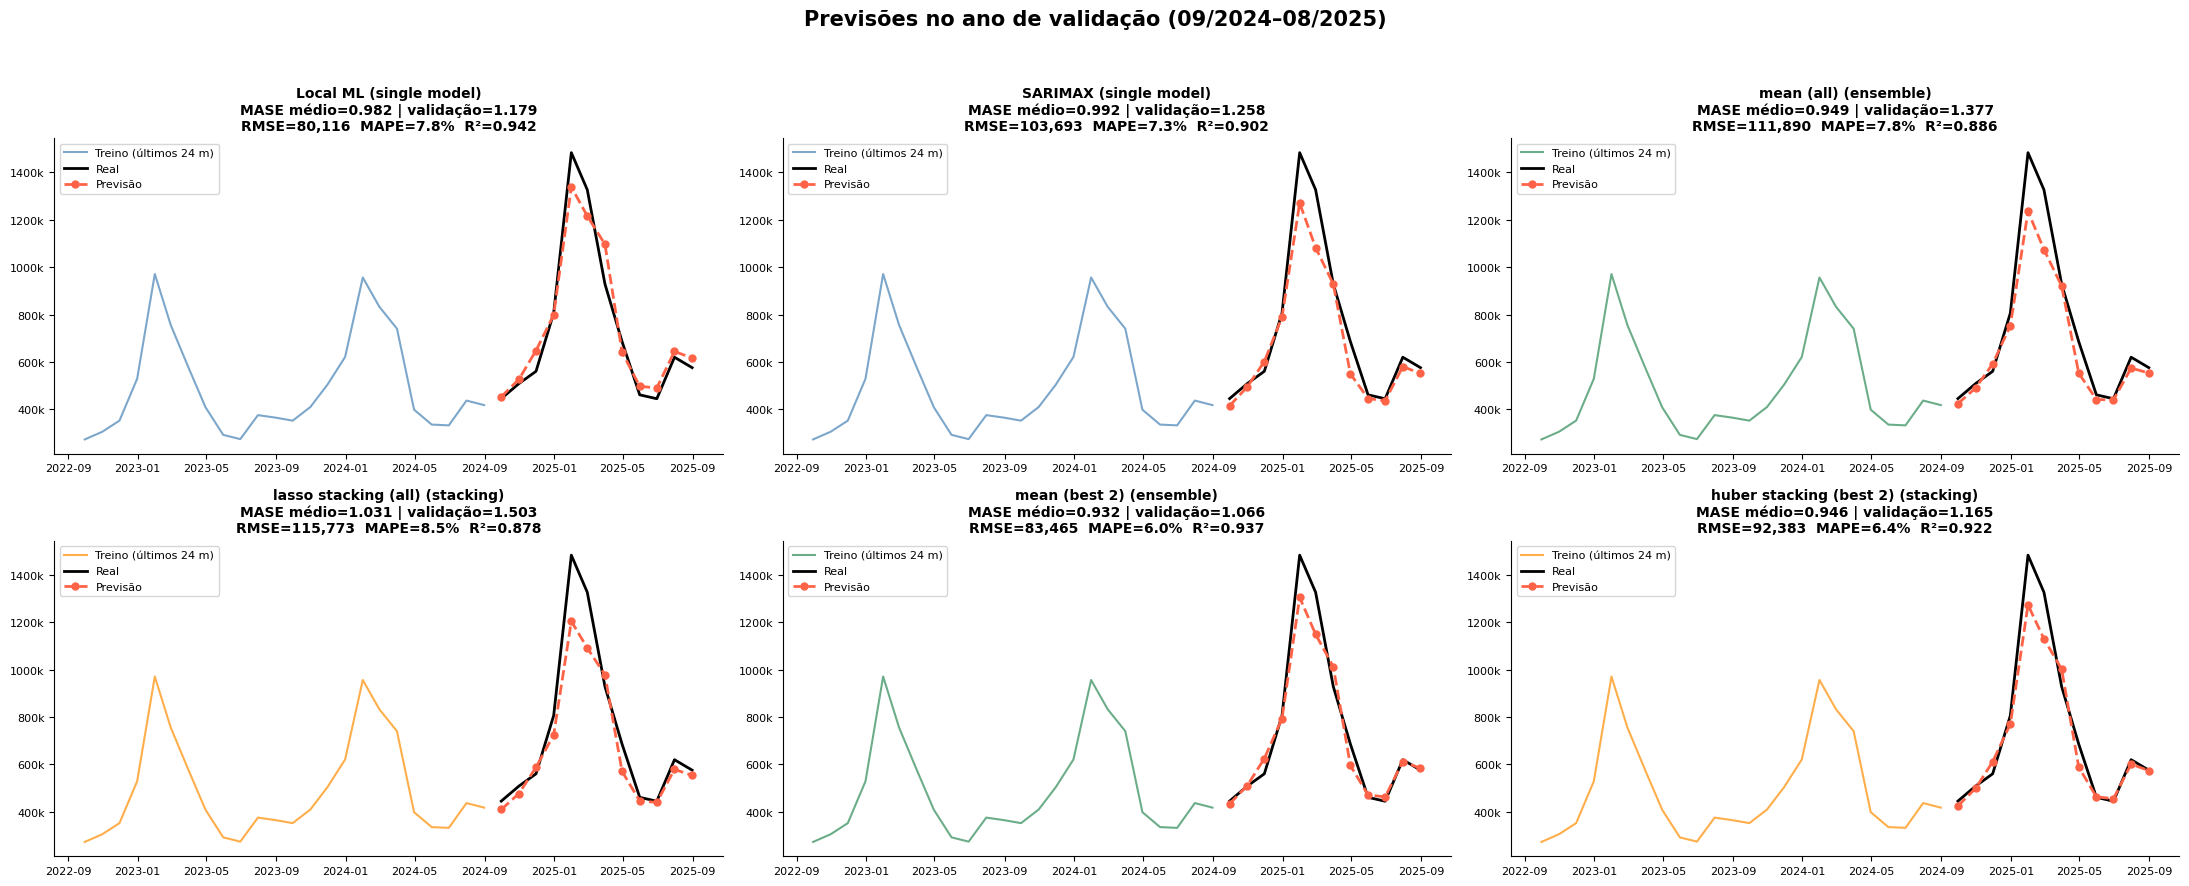

In [9]:
best_ens_all = summary[(summary['kind'] == 'ensemble') & (summary['subset'] == 'all')].index[0]
best_stk_all = summary[(summary['kind'] == 'stacking') & (summary['subset'] == 'all')].index[0]
best_ens_b2 = summary[(summary['kind'] == 'ensemble') & (summary['subset'] == 'best 2')].index[0]
best_stk_b2 = summary[(summary['kind'] == 'stacking') & (summary['subset'] == 'best 2')].index[0]

PANELS = [
    best_single,
    BEST_2_APPROACHES[1],
    best_ens_all,
    best_stk_all,
    best_ens_b2,
    best_stk_b2,
]
latest = forecasts.xs(LATEST, level='origin')
history = full_series.loc[: ORIGINS[LATEST]].iloc[-24:]

fig, axes = plt.subplots(2, 3, figsize=(22, 9))
fig.suptitle(
    f'Previsões no ano de validação ({latest.index[0]:%m/%Y}–{latest.index[-1]:%m/%Y})',
    fontsize=15,
    fontweight='bold',
)
for ax, name in zip(axes.flat, PANELS):
    predicted = (
        latest[name]
        if name in APPROACHES
        else ensembles[name].xs(LATEST, level='origin')
    )
    row = summary.loc[name]
    ax.plot(
        history.index,
        history.values,
        color=COLORS[KIND[name]],
        alpha=0.7,
        label='Treino (últimos 24 m)',
    )
    ax.plot(latest.index, latest['actual'], color='black', linewidth=2, label='Real')
    ax.plot(
        latest.index,
        predicted,
        color='tomato',
        linestyle='--',
        marker='o',
        markersize=5,
        linewidth=2,
        label='Previsão',
    )
    title_text = (
        f'{name} ({KIND[name]})\n'
        f'MASE médio={row["MASE_mean"]:.3f} | validação={row["MASE"]:.3f}\n'
        f'RMSE={row["RMSE"]:,.0f}  MAPE={row["MAPE"]:.1f}%  R²={row["R2"]:.3f}'
    )
    ax.set_title(
        title_text,
        fontsize=10,
        fontweight='bold',
    )
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x / 1000)}k'))
    ax.tick_params(labelsize=8)
    ax.legend(fontsize=8)
    sns.despine(ax=ax)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


## 6. Registro no MLflow

Registra cada combinação no experimento `Brazil Tourism Forecasting Ensembles` com o artefato `validation_forecasts.csv`.


In [10]:
def finite(value):
    return isinstance(value, (int, float, np.number)) and np.isfinite(value)


for name in ensembles:
    is_best2 = '(best 2)' in name
    members_list = BEST_2_APPROACHES if is_best2 else APPROACHES
    subset_tag = 'best_2' if is_best2 else 'all'

    params = {
        'method': name,
        'subset': subset_tag,
        'members': ', '.join(members_list),
        **{f'member_{a}': members[a]['configuration'][:500] for a in members_list},
        'eval_split': 'validation',
        'origins': ', '.join(ORIGIN_LABELS),
        'selection_metric': 'mean_seasonal_mase',
    }
    if 'huber stacking' in name:
        params['huber_params'] = json.dumps(HUBER_PARAMS)
        params['evaluation'] = 'leave one origin out'
        final_mod = final_huber_models[name]
        params['final_weights'] = json.dumps(
            dict(zip(members_list, np.round(final_mod.coef_, 4).tolist()))
        )
    if 'inverse-MASE mean' in name:
        params['evaluation'] = 'leave one origin out'
        final_w = inverse_mase_weights(ORIGIN_LABELS, members_list)
        params['final_weights'] = json.dumps(
            final_w.round(4).to_dict()
        )
    if name in final_stackers:
        final_fit, final_alpha = final_stackers[name]
        params['evaluation'] = (
            'leave one origin out (penalty: nested leave one origin out)'
        )
        params['final_alpha'] = final_alpha
        params['final_weights'] = json.dumps(
            dict(zip(members_list, np.round(final_fit.coef_, 4).tolist()))
        )
    # the validation forecasts (leave-one-origin-out for the weighted methods), in the
    # same format as the best-configuration forecasts of notebooks 5-9
    validation_forecasts = (
        forecasts[['actual']].assign(forecast=ensembles[name]).reset_index()
    )
    with mlflow.start_run(run_name=f'ensemble | {name}'):
        mlflow.set_tags({
            'role': 'ensemble_validation_forecasts',
            'kind': KIND[name],
            'subset': subset_tag,
        })
        mlflow.log_params(params)
        mlflow.log_metrics({
            key.replace(' ', '_'): float(value)
            for key, value in results[name].items()
            if finite(value)
        })
        mlflow.log_text(
            validation_forecasts.to_csv(index=False), 'validation_forecasts.csv'
        )
print(f'Logged {len(ensembles)} runs to "{EXPERIMENT_NAME}"')


Logged 13 runs to "Brazil Tourism Forecasting Ensembles"


## Leitura dos Resultados
